<a href="https://colab.research.google.com/github/marynatarasevych/ML_Study/blob/main/Tarasevych_%22HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
!wget -q https://raw.githubusercontent.com/marynatarasevych/ML_Study/refs/heads/main/process_bank_churn.py

In [2]:
from process_bank_churn import preprocess_data

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
raw_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Train Data.csv")

In [6]:
#preprocess_data
result = preprocess_data(
    raw_df,
    target='Exited',
    cols_to_drop_name=['id', 'CustomerId', 'Surname'],
    scaler_numeric=False
)

X_train = result['X_train']
train_targets = result['train_targets']
X_val = result['X_val']
val_targets = result['val_targets']
input_cols = result['input_cols']
scaler = result['scaler']
encoder = result['encoder']

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [7]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [8]:
from typing import Any
def compute_auroc_and_build_roc(model: Any, inputs, targets, name: str = '') -> float:
    """
    Вычисляет AUROC для заданной модели и данных.

    Args:
        model: обученная модель с методом predict_proba (например, DecisionTreeClassifier).
        inputs: признаки (X_train, X_val и т.п.).
        targets: истинные значения таргета.
        name: подпись для графика и вывода (например, 'Train', 'Validation', 'Decision Tree').

    Returns:
        Значение AUROC (float).
    """
    # Predict probabilities
    y_pred_proba = model.predict_proba(inputs)[:, 1]

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {roc_auc:.6f}')

    return roc_auc

In [9]:
auc_train = compute_auroc_and_build_roc(knn, X_train, train_targets, 'Training')
auc_val   = compute_auroc_and_build_roc(knn, X_val, val_targets, 'Validation')
print(f'Gap (train - val): {auc_train - auc_val:.4f}')

AUROC for Training: 0.822773
AUROC for Validation: 0.578315
Gap (train - val): 0.2445


**Висновки**

**Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?**

Модель погано прогнозує таргет на валідаційних даних, оскільки AUROC всього 0,578. Модель має high variance - різниця в AUROC між тренувальним і валідаційним набором 0,245, що говорить про перенавчання


2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [15]:
params_knn = {'n_neighbors': np.arange(1, 151)}
knn_gs = GridSearchCV(knn, params_knn, cv=5, scoring='roc_auc',)
knn_gs.fit(X_train, train_targets)
knn_best = knn_gs.best_estimator_

print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(144)} 0.6013865306888964


In [16]:
auc_train_best = compute_auroc_and_build_roc(knn_best, X_train, train_targets, 'Training (knn_best)')
auc_val_best   = compute_auroc_and_build_roc(knn_best, X_val, val_targets, 'Validation (knn_best)')
print(f'Gap: {auc_train_best - auc_val_best:.4f}')

AUROC for Training (knn_best): 0.627017
AUROC for Validation (knn_best): 0.624219
Gap: 0.0028


**Висновки**

**зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?**

 Оптимальна кількість сусідів - 144. Це доволі багато, проте AUROC на валідаційних даних трохи покращився, в порівнянні з попереднім завданням, і став 0,624. Різниці між тренувальним і валідаційним набором даних майже немає - 0,0028. За допомогою опшуку оптимального гіперпараметра модель більше не має high variance, проте тепер має high bias, оскліьки значення AUROC дуже низьке. На моделі дерева прийняття рішель, AUROC на валідаційному наборі був 0.924879

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [20]:
import time

param_grid = {'max_depth': np.arange(1, 21, 2), 'max_leaf_nodes': np.arange(2, 11, 1)}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3, scoring='roc_auc')

start = time.time()
dt_gs.fit(X_train, train_targets)
print(f'Час пошуку: {time.time() - start:.2f} с')

dt_best = dt_gs.best_estimator_
print(dt_gs.best_params_, dt_gs.best_score_)

Час пошуку: 7.81 с
{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)} 0.896755388100145


In [41]:
auc_train_dt_best = compute_auroc_and_build_roc(dt_best, X_train, train_targets, 'Training (dt_best)')
auc_val_dt_best   = compute_auroc_and_build_roc(dt_best, X_val, val_targets, 'Validation (dt_best)')
print(f'Gap: {auc_train_dt_best - auc_val_dt_best:.4f}')

AUROC for Training (dt_best): 0.901013
AUROC for Validation (dt_best): 0.901845
Gap: -0.0008


В попередньому домашньому завданні моя найкраща модель мала max_depth=8 та max_leaf_nodes=45 (AUROC на валідації = 0.924879). Спробую знайти оптимальні гіперпараметри для більшого набору можливих значень щоб перевірити, чи дійсно моя попередня модель була найкращою

In [21]:
import time

param_grid_1 = {'max_depth': np.arange(1, 21, 1), 'max_leaf_nodes': np.arange(2, 200, 1)}
dt_gs_1 = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_1, cv=3, scoring='roc_auc')

start = time.time()
dt_gs_1.fit(X_train, train_targets)
print(f'Час пошуку: {time.time() - start:.2f} с')

dt_best_1 = dt_gs_1.best_estimator_
print(dt_gs_1.best_params_, dt_gs_1.best_score_)

Час пошуку: 410.80 с
{'max_depth': np.int64(7), 'max_leaf_nodes': np.int64(38)} 0.9188686872764359


Найкращий вийшов з параметрами max_depth = 7 і max_leaf_nodes = 38

In [40]:
auc_train_dt_best = compute_auroc_and_build_roc(dt_best_1, X_train, train_targets, 'Training (dt_best_1)')
auc_val_dt_best   = compute_auroc_and_build_roc(dt_best_1, X_val, val_targets, 'Validation (dt_best_1)')
print(f'Gap: {auc_train_dt_best - auc_val_dt_best:.4f}')

AUROC for Training (dt_best_1): 0.928452
AUROC for Validation (dt_best_1): 0.923109
Gap: 0.0053


** Висновки **

**Чи ця модель краща за ту, що ви знайшли вручну?**

В попередньому домашньому завданні:   

    AUROC на трейні = 0.930379
    AUROC на валідації = 0.924879
З пошуком оптимальних гіперпараметрів за допомогою GridSearchCV по заданій сітці в завданні:

    AUROC на трейні = 0.901013
    AUROC на валідації = 0.901845

З пошуком оптимальних гіперпараметрів за допомогою GridSearchCV по мною заданою сіткою:

    AUROC на трейні = 0.928452
    AUROC на валідації = 0.923109

Модель, знайдена вручну в минуломі завданні все одно краща

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [31]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    params_dt,
    n_iter = 40,
    cv = 3,
    scoring="roc_auc",
    refit=True,
    random_state=42
)
start = time.time()
dt_search.fit(X_train, train_targets)
print(f'Час пошуку: {time.time() - start:.2f} с')

Час пошуку: 1.89 с


In [43]:
dt_random_search_best = dt_search.best_estimator_
print(dt_search.best_params_, dt_search.best_score_)

{'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'} 0.9118622813318175


In [44]:
auc_train_dt_random_search_best = compute_auroc_and_build_roc(dt_random_search_best, X_train, train_targets, 'Training (dt_random_search_best)')
auc_val_dt_random_search_best   = compute_auroc_and_build_roc(dt_random_search_best, X_val, val_targets, 'Validation (dt_random_search_best)')
print(f'Gap: {auc_train_dt_random_search_best - auc_val_dt_random_search_best:.4f}')

AUROC for Training (dt_random_search_best): 0.916613
AUROC for Validation (dt_random_search_best): 0.917600
Gap: -0.0010


**Висновки**

**Чи ця модель краща за ту, що ви знайшли з GridSearch? - проаналізуйте параметри dt_random_search_best і порівняйте з параметрами dt_best - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування DecisionTreeClassifier впливають на якість моделі.**

Ця модель краща за ту, що я знайшла з GridSearch з заданими в задачі параметрами. Але гірша за ту, що я знайшла зі своїми параметрами в GridSearch.

Відмінність параметрів:

  'max_leaf_nodes': np.int64(14),'max_depth': np.int64(16)


В random_search додані такі параметри як:
    
    'criterion': ['gini', 'entropy'] - по дефолту gini - по random_search - entropy
    'splitter': ['best', 'random'] - по дефолту  best - по random_search - best
    'min_samples_split': [2, 5, 10, 20] - по дефолту  2 - по random_search - 20
    'min_samples_leaf': [1, 2, 4, 8] - по дефолту  1 - по random_search - 2
    'max_features': [None, 'sqrt', 'log2'] - по дефолту  None - по random_search - None

Залишились ті ж параметри, що і в GridSearch:
    
    'max_depth': np.arange(1, 20) - по дефолту None - GridSearch - від 1 до 20 з кроком 2 - random_search - від 1 до 19 з кроком 1
    'max_leaf_nodes': np.arange(2, 20) - по дефолту None - GridSearch - від 2 до 10 з кроком 1 - random_search - від 2 до 19 з кроком 1

Кількість ітерацій задана всього 40, що дуже мало для такого великого вибору параметрів.

В моїй моделі було більше max_leaf_nodes та max_depth. Спробую натренувати моделі з random_search з більшою кількістю параметрів і ітерацій


In [45]:
params_dt_my = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 21),
    'max_leaf_nodes': np.arange(2, 101),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}
dt_search_my = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    params_dt_my,
    n_iter = 100,
    cv = 3,
    scoring="roc_auc",
    refit=True,
    random_state=42
)
start = time.time()
dt_search_my.fit(X_train, train_targets)
print(f'Час пошуку: {time.time() - start:.2f} с')

dt_random_search_my_best = dt_search_my.best_estimator_
print(dt_search_my.best_params_, dt_search_my.best_score_)

auc_train_dt_random_search_my_best = compute_auroc_and_build_roc(dt_random_search_my_best, X_train, train_targets, 'Training (dt_random_my_search_best)')
auc_val_dt_random_search_my_best   = compute_auroc_and_build_roc(dt_random_search_my_best, X_val, val_targets, 'Validation (dt_random_my_search_best)')
print(f'Gap: {auc_train_dt_random_search_my_best - auc_val_dt_random_search_my_best:.4f}')

Час пошуку: 5.52 с
{'splitter': 'random', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_leaf_nodes': np.int64(49), 'max_features': None, 'max_depth': np.int64(14), 'criterion': 'entropy'} 0.9181112913494518
AUROC for Training (dt_random_my_search_best): 0.921287
AUROC for Validation (dt_random_my_search_best): 0.909164
Gap: 0.0121


In [46]:
from sklearn.model_selection import cross_val_score
dt_manual = DecisionTreeClassifier(max_depth=8, max_leaf_nodes=45, random_state=42)
print(cross_val_score(dt_manual, X_train, train_targets, cv=3, scoring='roc_auc').mean())

0.9158114608475961


**Висновки по всім моделям**

Мій останінй Random_search дав на валідації гірший результат. Це обмовлено рамдомнім пошуком, а не перебором всіх параметрів. Оскільки всього було 100 вариацій, шанс попасти в найкращий гіперпараметр не високий.

Моя модель, підібрана руками в минулому ДЗ, яка мала AUROC на трейні = 0.930379, була натренована на всьому наборі тренувальних данних, без крос-валідації. Натренувавши з врахуванням крос-валідації CV AUROC на трейні = 0,916. А це нижче за CV AUROC на останній моделі з GridSearchCV (0.919)

Спробую натренувати GridSearchCV з більшою кількістю параметрів, але меншим вибором  max_depth і max_leaf_nodes

In [49]:
param_grid_my =  {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 16),
    'max_leaf_nodes': np.arange(2, 60),
   # 'min_samples_split': [2, 5, 10, 20], -- прибрано спеціально
   # 'min_samples_leaf': [1, 2, 4, 8], -- прибрано спеціально
    'max_features': [None, 'sqrt', 'log2']
}
dt_gs_my = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_my, cv=3, scoring='roc_auc', n_jobs=-1)

start = time.time()
dt_gs_my.fit(X_train, train_targets)
print(f'Час пошуку: {time.time() - start:.2f} с')

dt_best_gs_my = dt_gs_my.best_estimator_
print(dt_gs_my.best_params_, dt_gs_my.best_score_)

auc_train_dt_best_gs_my = compute_auroc_and_build_roc(dt_best_gs_my, X_train, train_targets, 'Training (dt_best_gs_my)')
auc_val_dt_best_gs_my   = compute_auroc_and_build_roc(dt_best_gs_my, X_val, val_targets, 'Validation (dt_best_gs_my)')
print(f'Gap: {auc_train_dt_best_gs_my - auc_val_dt_best_gs_my:.4f}')

Час пошуку: 493.14 с
{'criterion': 'entropy', 'max_depth': np.int64(6), 'max_features': None, 'max_leaf_nodes': np.int64(23), 'splitter': 'best'} 0.9219708148445215
AUROC for Training (dt_best_gs_my): 0.926101
AUROC for Validation (dt_best_gs_my): 0.922628
Gap: 0.0035


CV AUROC на трейні = 0,922 - найвищий результат
AUROC на трейні = 0.926101
AUROC на валідації = 0.922628

Спробую залити 2 submission - по
1) {'max_depth': np.int64(7), 'max_leaf_nodes': np.int64(38)} 0.9188686872764359
2) {'criterion': 'entropy', 'max_depth': np.int64(6), 'max_features': None, 'max_leaf_nodes': np.int64(23), 'splitter': 'best'} 0.9219708148445215

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [50]:
from process_bank_churn import preprocess_new_data
test_raw_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Test Data.csv")
X_test = preprocess_new_data(
    test_raw_df,
    input_cols=result['input_cols'],
    scaler=result['scaler'],
    encoder=result['encoder'],
    imputer_cat=result['imputer_cat'],
    imputer_num=result['imputer_num'],
)

In [51]:
sample_submission_grid_min_param = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Sample Submission.csv")

In [52]:
test_preds_proba_grid_min_param = dt_best_1.predict_proba(X_test)[:, 1]

In [53]:
sample_submission_grid_min_param['Exited'] = test_preds_proba_grid_min_param
sample_submission_grid_min_param

,id,Exited
0,15000,0.058824
1,15001,0.014736
2,15002,0.014736
3,15003,0.759434
4,15004,0.014736
...,...,...
9995,24995,0.014736
9996,24996,0.014736
9997,24997,0.014736
9998,24998,0.041061


In [54]:
sample_submission_grid_min_param.to_csv('/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/submission_dt_grid_min.csv', index=False)

In [55]:
test_preds_proba_grid_max_param = dt_best_gs_my.predict_proba(X_test)[:, 1]

In [56]:
sample_submission_grid_max_param = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Sample Submission.csv")

In [58]:
sample_submission_grid_max_param['Exited'] = test_preds_proba_grid_max_param
sample_submission_grid_max_param

,id,Exited
0,15000,0.231405
1,15001,0.012522
2,15002,0.143631
3,15003,0.440972
4,15004,0.061818
...,...,...
9995,24995,0.012522
9996,24996,0.012522
9997,24997,0.012522
9998,24998,0.038175


In [59]:
sample_submission_grid_max_param.to_csv('/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/submission_dt_grid_max.csv', index=False)

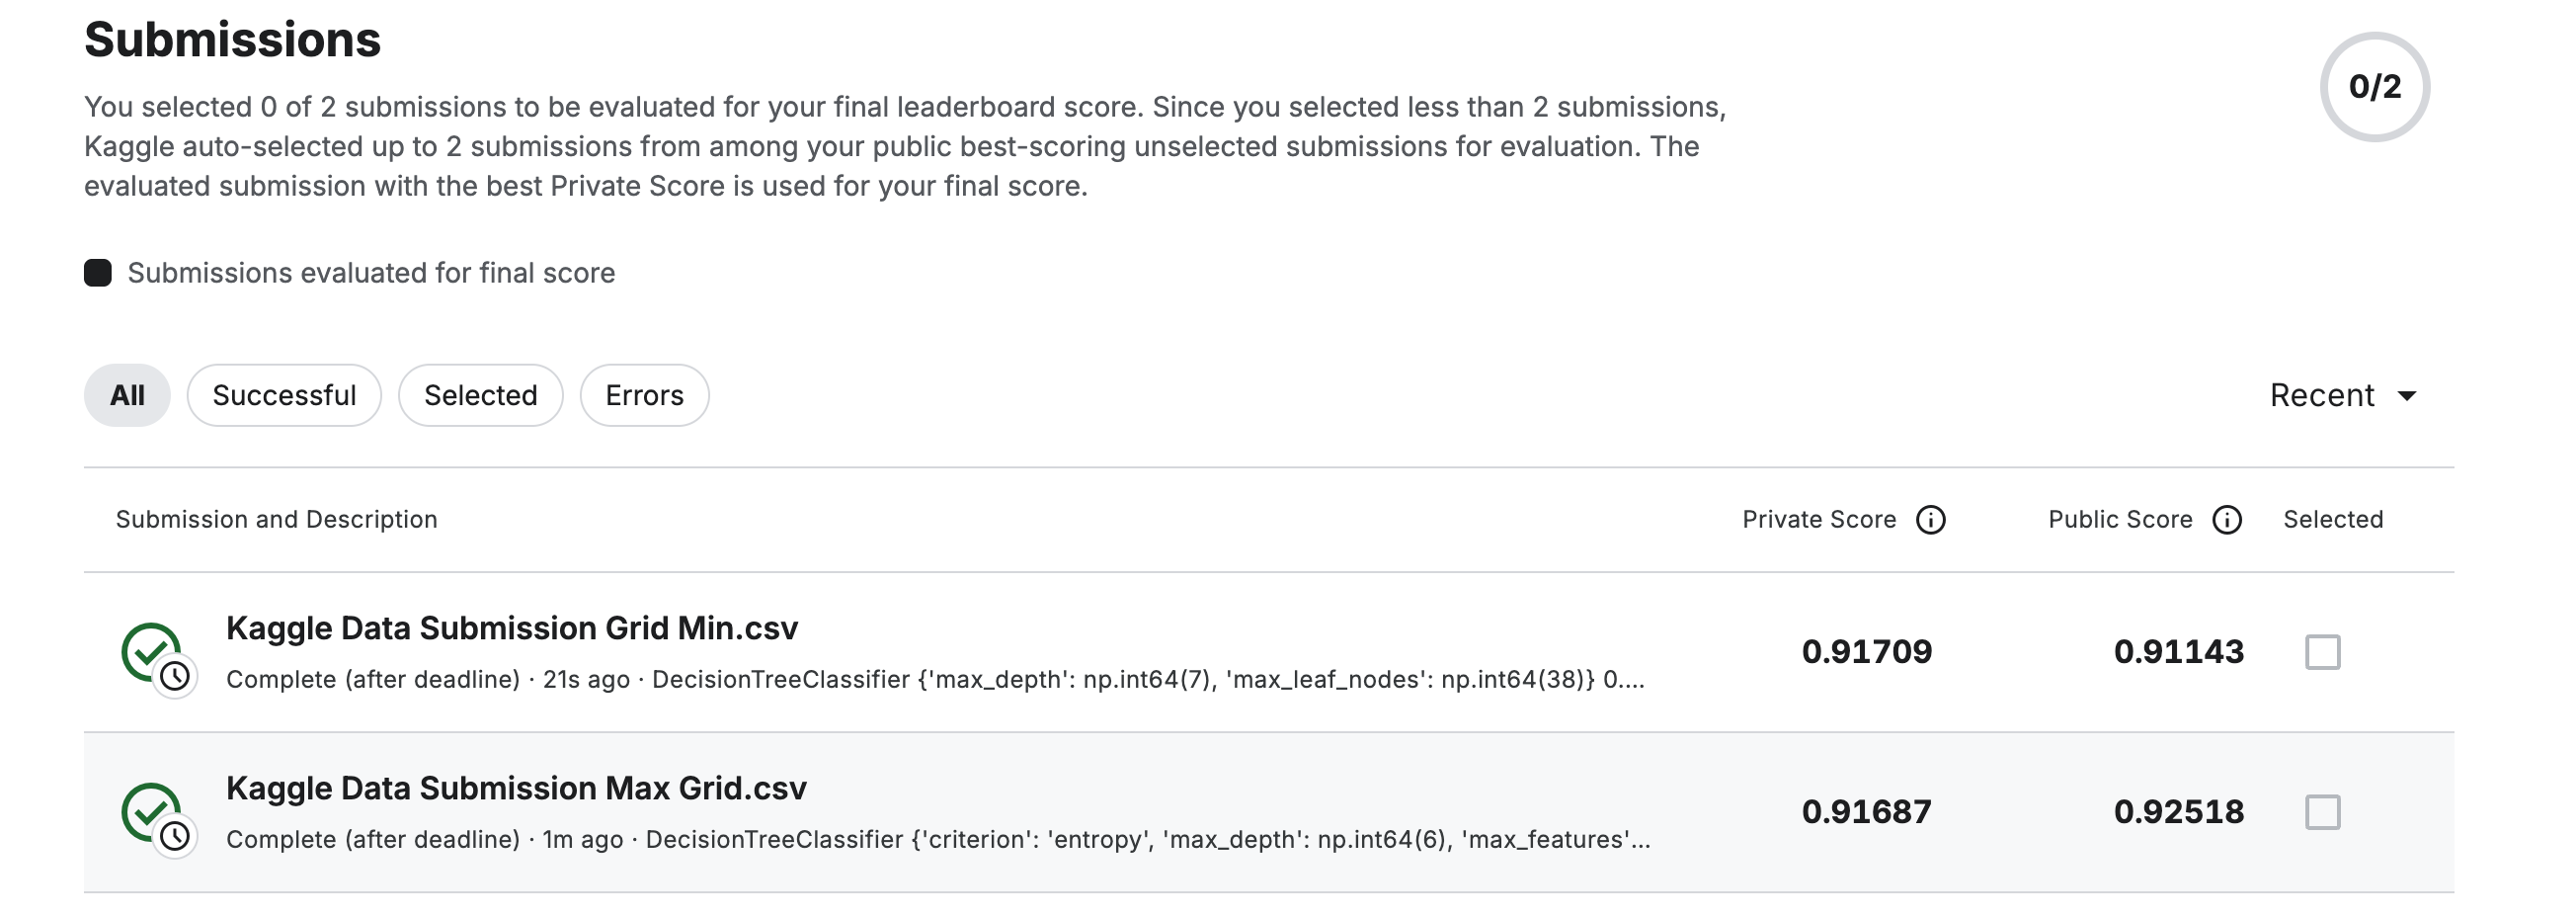